In [12]:
# %%
"""
EDA Notebook for Analyst Ratings CSV
Columns expected: headline, publisher, url, date, stock
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF
from scipy.stats import zscore
from datetime import datetime

pd.options.display.max_colwidth = 200

CSV_PATH = "data/raw_analyst_ratings.csv"  


In [13]:
# %%
import pandas as pd

CSV_PATH = "../data/raw_analyst_ratings.csv"

try:
    df = pd.read_csv(CSV_PATH)
    print("CSV loaded successfully!")
except FileNotFoundError:
    raise FileNotFoundError(f"CSV not found at: {CSV_PATH}")

df.head()


CSV loaded successfully!


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/stocks-that-hit-52-week-highs-on-friday,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/stocks-that-hit-52-week-highs-on-wednesday,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/71-biggest-movers-from-friday,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/46-stocks-moving-in-fridays-mid-day-session,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,"B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88",https://www.benzinga.com/news/20/05/16095304/b-of-a-securities-maintains-neutral-on-agilent-technologies-raises-price-target-to-88,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [14]:
# %%
# Clean whitespace
df['headline'] = df['headline'].astype(str).str.strip()
df['publisher'] = df['publisher'].astype(str).str.strip()

# Parse date column
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')

print("Parsed dates:", df['date_parsed'].notna().sum(), "/", len(df))


Parsed dates: 55987 / 1407328


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


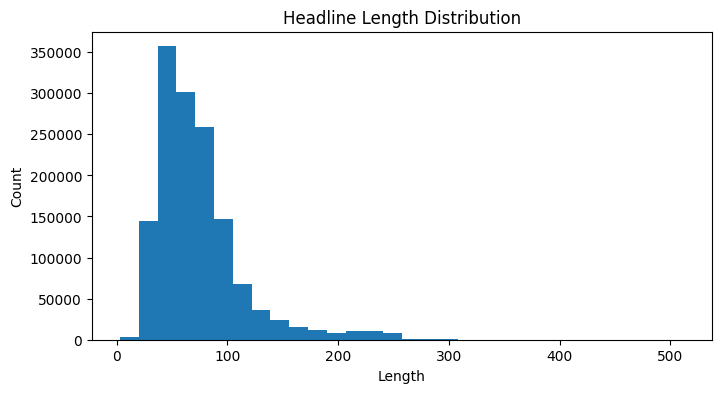

In [15]:
# %%
df['headline_len'] = df['headline'].apply(lambda x: len(x))

print(df['headline_len'].describe())

plt.figure(figsize=(8,4))
plt.hist(df['headline_len'], bins=30)
plt.title("Headline Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64


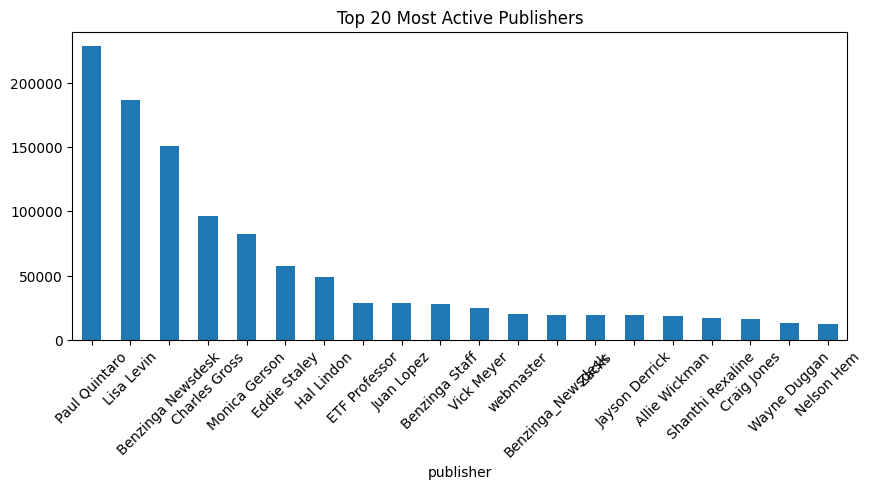

In [16]:
# %%
publisher_counts = df['publisher'].value_counts()

print(publisher_counts.head(20))

plt.figure(figsize=(10,4))
publisher_counts.head(20).plot(kind='bar')
plt.title("Top 20 Most Active Publishers")
plt.xticks(rotation=45)
plt.show()


Spike Days (z > 2):
            date  count          z
2425  2020-02-27    275   3.711301
2426  2020-02-28    381   5.267135
2433  2020-03-06    281   3.799367
2437  2020-03-11    282   3.814044
2438  2020-03-12    973  13.956326
2445  2020-03-19    629   8.907201
2449  2020-03-23    375   5.179069
2450  2020-03-24    160   2.023367
2465  2020-04-09    164   2.082077
2468  2020-04-13    184   2.375631
2470  2020-04-15    186   2.404986
2471  2020-04-16    199   2.595796
2472  2020-04-17    194   2.522408
2475  2020-04-20    180   2.316920
2476  2020-04-21    233   3.094838
2477  2020-04-22    245   3.270970
2478  2020-04-23    265   3.564524
2479  2020-04-24    246   3.285648
2482  2020-04-27    283   3.828722
2483  2020-04-28    317   4.327763
2484  2020-04-29    449   6.265218
2485  2020-04-30    488   6.837648
2486  2020-05-01    385   5.325846
2489  2020-05-04    347   4.768094
2490  2020-05-05    478   6.690871
2491  2020-05-06    531   7.468788
2492  2020-05-07    749  10.668524


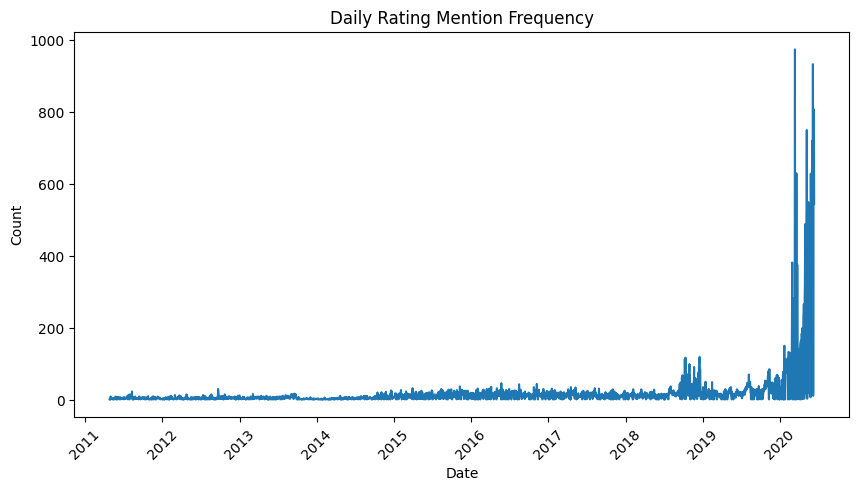

In [ ]:
# %%
from scipy.stats import zscore


df['date'] = pd.to_datetime(df['date'], errors='coerce')


daily_df = df.groupby(df['date'].dt.date).size().reset_index(name="count")

daily_df['z'] = zscore(daily_df['count'])

print("Spike Days (z > 2):")
print(daily_df[daily_df['z'] > 2])

plt.figure(figsize=(10,5))
plt.plot(daily_df['date'], daily_df['count'])
plt.title("Daily Rating Mention Frequency")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


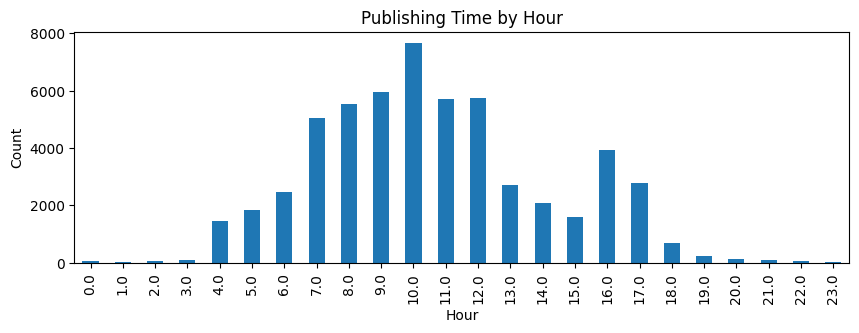

In [19]:
# %%
df['pub_hour'] = df['date_parsed'].dt.hour

hour_counts = df['pub_hour'].value_counts().sort_index()

plt.figure(figsize=(10,3))
hour_counts.plot(kind='bar')
plt.title("Publishing Time by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()


In [ ]:
# %%  (Cell 8 -- FAST VERSION)


df["clean_headline"] = df["headline"].str.lower()

df["clean_headline"] = df["clean_headline"].str.replace(r"[^a-z0-9\s]", " ", regex=True)

df["clean_headline"] = df["clean_headline"].str.replace(r"\s+", " ", regex=True).str.strip()

print("Sample cleaned headlines:")
df["clean_headline"].head()


Sample cleaned headlines:


355064                                                  etfs to watch april 28 2011 dgp ieo prn idx
435456                                                          a new regional emerging markets etf
348178                       dejour extends credit facility to october 31st facility cut to 4 5 dej
48673                                                     etf showdown crouching tigers hidden etfs
536537    the gdl fund to redeem its outstanding 8 50 series a cumulative callable preferred shares
Name: clean_headline, dtype: object

In [26]:
# %% (Cell 9 — Fast Topic Modeling)

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import MiniBatchNMF 

print("Vectorizing...")

vec = CountVectorizer(
    stop_words='english',
    min_df=20,          # ignore very rare words
    max_df=0.5,         # ignore extremely common words
    max_features=5000   # limit vocabulary size
)

X = vec.fit_transform(df["clean_headline"])

print("Vectorization completed.")

nmf = MiniBatchNMF(
    n_components=5, 
    random_state=42,
    batch_size=512
)

print("Fitting NMF model...")
nmf.fit(X)
print("Model trained.")

# Show top words in each topic
words = vec.get_feature_names_out()

for topic_idx, topic in enumerate(nmf.components_):
    print(f"\nTopic #{topic_idx + 1}:")
    top_indices = topic.argsort()[-10:]
    print([words[i] for i in top_indices])


Vectorizing...
Vectorization completed.
Fitting NMF model...
Model trained.

Topic #1:
['q4', 'q1', 'q2', 'revenue', 'q3', 'sales', 'eps', 'reports', 'est', 'vs']

Topic #2:
['highs', 'update', 'hitting', 'morning', 'mid', '52', 'week', 'etfs', 'market', 'stocks']

Topic #3:
['news', 'morning', 'share', 'higher', 'pt', 'announces', 'mid', 'market', 'update', 'shares']

Topic #4:
['maintains', 'neutral', 'coverage', 'buy', 'initiates', 'raises', 'downgrades', 'announces', '00', 'pt']

Topic #5:
['amid', 'companies', 'lows', 'new', 'shares', 'trading', 'hitting', 'highs', '52', 'week']


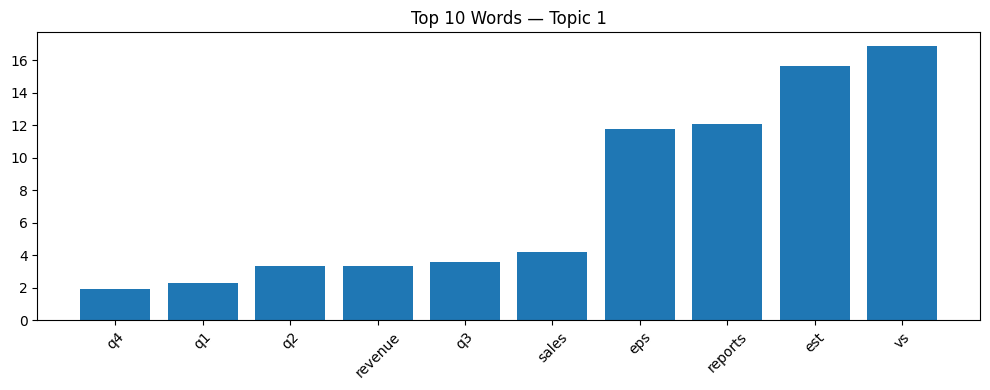

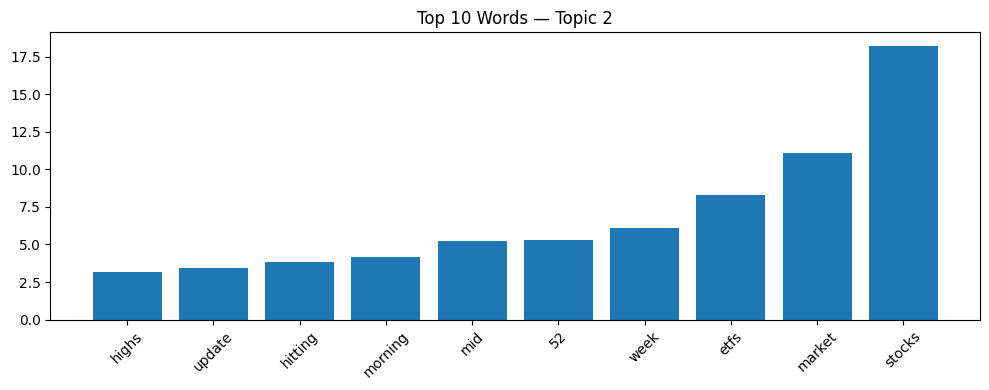

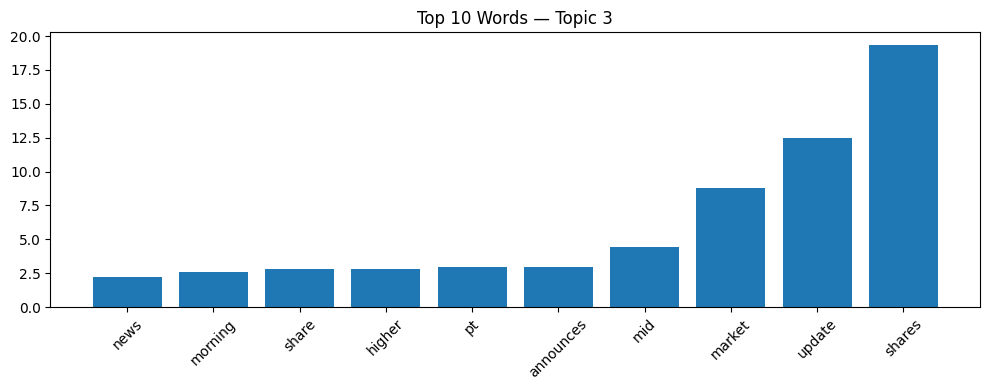

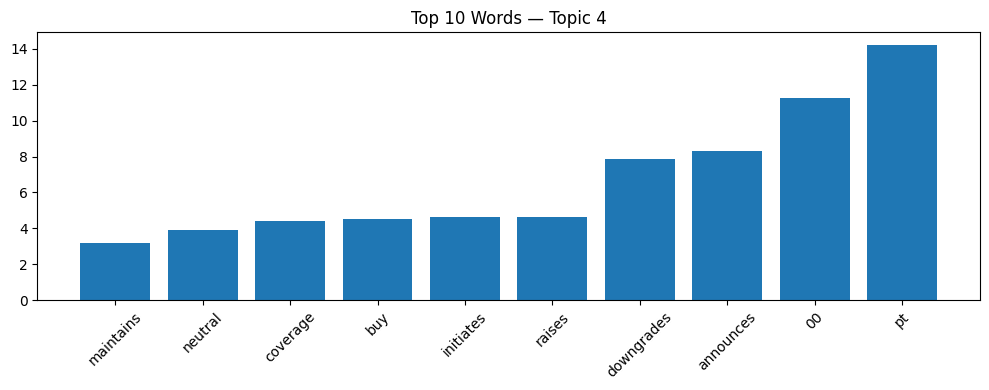

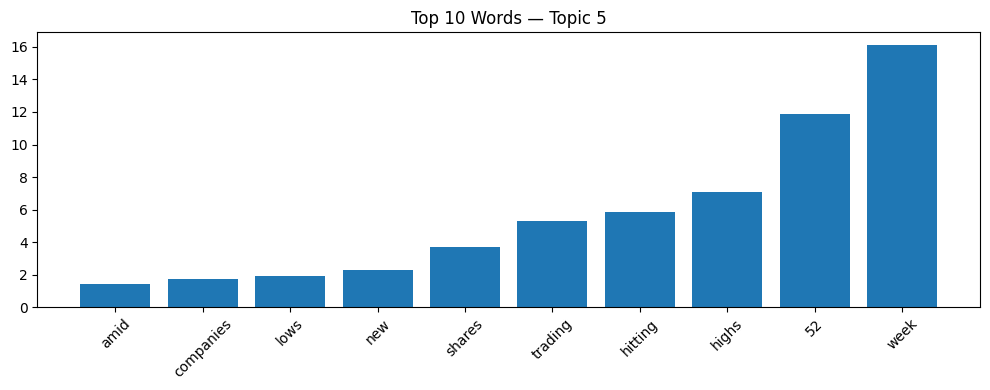

In [27]:
# %% (Cell 10 — Bar Charts for Topics)

import matplotlib.pyplot as plt

words = vec.get_feature_names_out()

for i, topic in enumerate(nmf.components_):
    top_indices = topic.argsort()[-10:]
    top_words = [words[j] for j in top_indices]
    top_values = topic[top_indices]

    plt.figure(figsize=(10, 4))
    plt.bar(top_words, top_values)
    plt.title(f"Top 10 Words — Topic {i+1}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


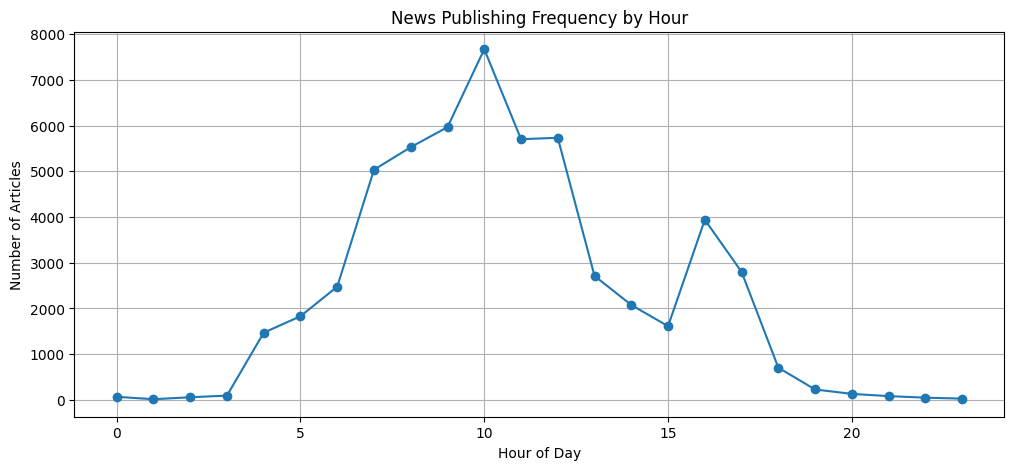

hour
0.0      67
1.0      14
2.0      57
3.0      93
4.0    1469
Name: count, dtype: int64

In [28]:
# %% (Cell 12 — Publishing Time Analysis)

import matplotlib.pyplot as plt

# Ensure datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract hour and weekday
df['hour'] = df['date'].dt.hour
df['weekday'] = df['date'].dt.day_name()

# Count frequency by hour
hour_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(hour_counts.index, hour_counts.values, marker='o')
plt.title("News Publishing Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")
plt.grid(True)
plt.show()

hour_counts.head()


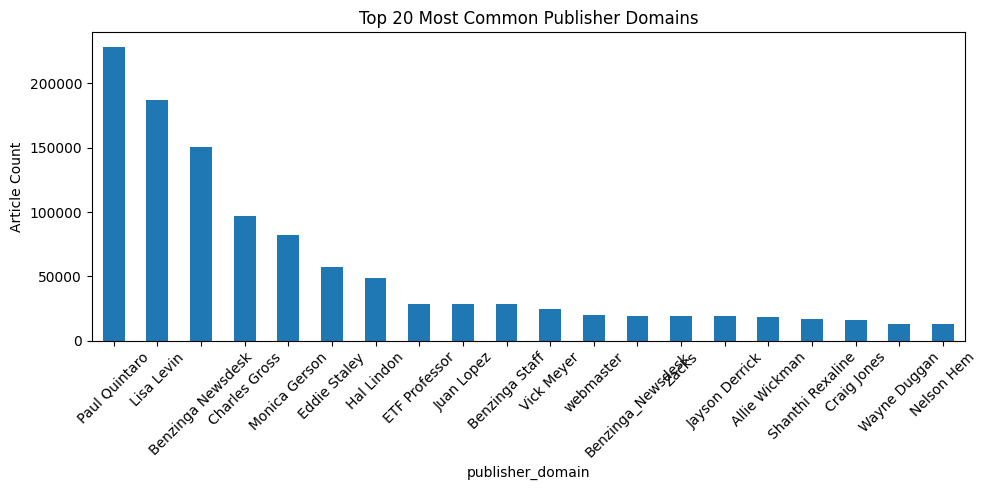

publisher_domain
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

In [29]:
# %% (Cell 13 — Publisher Domain Analysis)

import re

def extract_domain(p):
    if isinstance(p, str):
        match = re.search(r"@([\w.-]+)", p)
        if match:
            return match.group(1)
    return p

df['publisher_domain'] = df['publisher'].apply(extract_domain)

domain_counts = df['publisher_domain'].value_counts().head(20)

plt.figure(figsize=(10, 5))
domain_counts.plot(kind='bar')
plt.title("Top 20 Most Common Publisher Domains")
plt.ylabel("Article Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

domain_counts


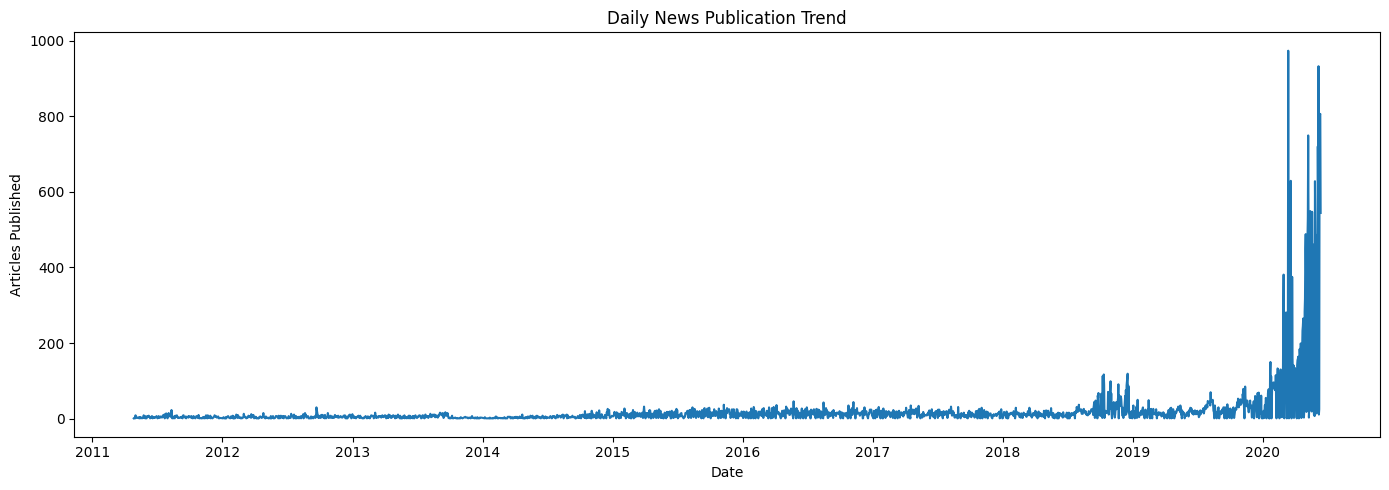

date
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
Name: count, dtype: int64

In [30]:
# %% (Cell 14 — Trend Over Time)

daily_counts = df['date'].dt.date.value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_counts.index, daily_counts.values)
plt.title("Daily News Publication Trend")
plt.xlabel("Date")
plt.ylabel("Articles Published")
plt.tight_layout()
plt.show()

daily_counts.head()


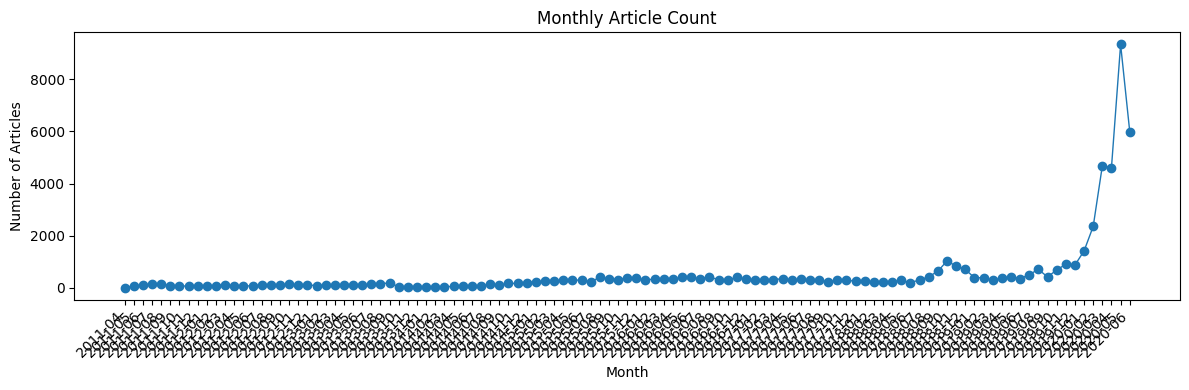

First 6 months:
date
2011-04      6
2011-05     78
2011-06     96
2011-07    137
2011-08    149
2011-09     90
Freq: M, Name: count, dtype: int64

Last 6 months:
date
2020-01    1417
2020-02    2356
2020-03    4680
2020-04    4616
2020-05    9333
2020-06    5990
Freq: M, Name: count, dtype: int64


In [36]:
import matplotlib.pyplot as plt

monthly_index = monthly.index.astype(str)
monthly_values = monthly.values

plt.figure(figsize=(12,4))
plt.plot(monthly_index, monthly_values, marker='o', linewidth=1)
plt.title("Monthly Article Count")
plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("First 6 months:")
print(monthly.head(6))
print("\nLast 6 months:")
print(monthly.tail(6))


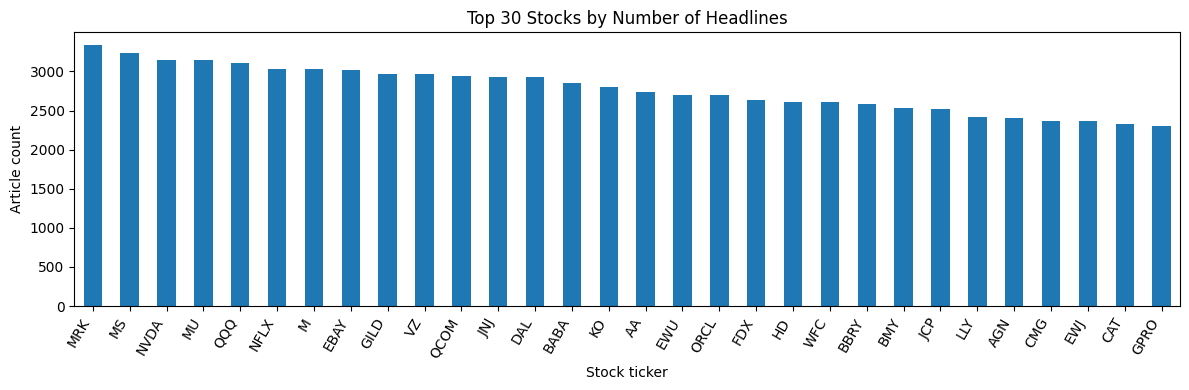

stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
QCOM    2941
JNJ     2928
DAL     2926
BABA    2858
KO      2797
AA      2739
EWU     2702
ORCL    2701
FDX     2629
HD      2612
WFC     2612
BBRY    2580
BMY     2528
JCP     2516
LLY     2417
AGN     2408
CMG     2370
EWJ     2362
CAT     2322
GPRO    2303
Name: count, dtype: int64

In [ ]:
# %%  (Cell 17 - Stock-level headline counts)

df['stock'] = df['stock'].astype(str).str.strip().replace({'nan': None})
stock_counts = df['stock'].value_counts().head(30)

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
stock_counts.plot(kind='bar')
plt.title("Top 30 Stocks by Number of Headlines")
plt.xlabel("Stock ticker")
plt.ylabel("Article count")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

display(stock_counts)
